---
 Title: Week 2 Scatterplots and Linear Regression    
 Author: Tres Reeves  
 Date: 21 June 2026  
 Description: Creating a scatterplot, and linear regression to answer questions around car weight and highway miles per gallon 

---
---
 Title: Matplotlib scatterplots     
 Author: Bro Code   
 Date: October 2025          
 Description: Understanding how to create customized scatter plots        
 URL: https://www.youtube.com/watch?v=HHrG5W530fk 

---
---
 Title: Solving Linear Regression in Python   
 Author: GeeksforGeeks 
 Date: 12 July 2025          
 Description: Learning to build Linear Regression lines in Python     
 URL: https://www.geeksforgeeks.org/machine-learning/solving-linear-regression-in-python/

---



In [1]:
# Importing libraries needed for the whole assignment 
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np 
from sklearn.linear_model import LinearRegression

**Question 1: Creating a scatterplot**   
Make a scatterplot of the highway miles per gallon (y-axis) versus the weight (x-axis).

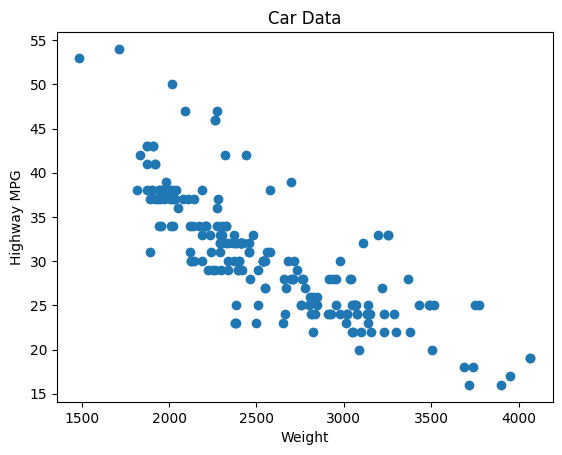

In [2]:
# Loading car data 
car_data_df = pd.read_csv('car_data.csv')

# Scatterplot x and y points 
plt.scatter(car_data_df['weight'], car_data_df['hwy_mpg'])

# Labeling axes and title   
plt.xlabel('Weight')
plt.ylabel('Highway MPG')
plt.title('Car Data')

plt.show() 


**Question 2: General Trend**   
Based on your plot, what is the general trend of how highway miles per gallon varies with the weight?  

Response 2:     
- **Based on the chart, we can see that the heavier a car is, the fewer miles per gallon it gets.**

**Question 3: Slope Expectation**   
If you were to build a linear model using this data to predict highway miles per gallon from weight,
would you expect the slope to be positive or negative? Explain.

Response 3: 
- **If I built a linear model to predict highway miles per gallon from weight, I expect a negative slope, because, as we can see, as weight increases from 1500 to 4000, miles per gallon decrease.**

**Question 4: Interpret Meaning**   
If the slope of a linear model predicting highway miles per gallon from the weight, interpret the meaning
of the slope being −0.05.

Response 4:   
- **For every pound the car increases in weight, the highway miles per gallon decreases by 0.05 miles per gallon.**

**Question 5: Adding a line**   
Write code to add a line to the graph you made in problem (1). Adjust the slope and y-intercept of this
line until you think you have found the line that best fits the data. Record the slope and y-intercept.

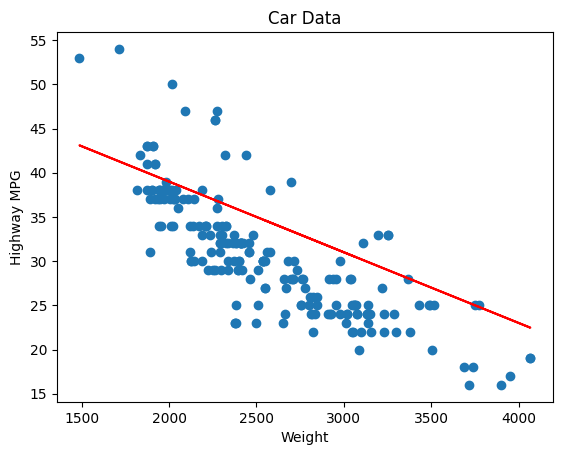

In [3]:
# Defining x and manual line parameters
x = car_data_df['weight']
m = -0.008
b = 55

# Scatterplot x and y points 
plt.scatter(x, car_data_df['hwy_mpg'])

# best-fit line using 'm x + b'
plt.plot(x, m * x + b, color='red')

# Labeling axes and title   
plt.xlabel('Weight')
plt.ylabel('Highway MPG')
plt.title('Car Data')

plt.show() 



**Question 6: Best-fit(least-squares)**   
Use Python to find the best-fit (least-squares) line. The Scikit-learn package is a good choice to use
for this.

In [4]:
# Defining the features and target variables
x = car_data_df[['weight']]
y = car_data_df['hwy_mpg']

# Regression model
model = LinearRegression()
model.fit(x, y)

# Printing best-fit slope and intercept 
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: -0.010547157168719581
Intercept: 57.70517422574473


**Question 7: Root Mean Squared Error (RMSE)**   
Find the root mean squared error (RMSE) of the prediction line you found in problem (5) and the
actual best-fit line found in problem (6). How do these compare? Is this what you would expect?

Response 7:   
- **The model RMSE is 4.14, while the manual RMSE is 5.77. This makes sense because sklearn's linear regression uses the least-squares method. Mathematically, finding the slope and intercept minimizes the sum of squared error. My manual line was a visual guess, so it's naturally going to be off. The sklearn line is the best possible straight line.**

In [5]:
# RMSE function
def calc_rmse(actual, predicted):

    # Converted inputs into numpy arrays 
    actual = np.array(actual)
    predicted = np.array(predicted)

    # Squared_diff variable finds the difference and squares it
    squared_diff = (predicted - actual) ** 2

    # Grabs the average of the squared differences
    avg_squared_error = np.mean(squared_diff)

    # Square root the average 
    rmse = np.sqrt(avg_squared_error)

    return rmse 

In [6]:
# Manual line prediction 
m = -0.008
b = 55

# Calculate predictions using manual slope and intercept 
y_pred_manual = m * car_data_df['weight'] + b

# Calculate predictions using sklearn best-fit line
y_pred_model = model.predict(car_data_df[['weight']])

# Calculate RMSE for both lines and compare 
rmse_manual = calc_rmse(car_data_df['hwy_mpg'], y_pred_manual)
rmse_model = calc_rmse(car_data_df['hwy_mpg'], y_pred_model)

# Printing results 
print("Manual RMSE:", rmse_manual)
print("Model RMSE:", rmse_model)

Manual RMSE: 5.779521985466255
Model RMSE: 4.144895442072008


**Question 8: Prediction**   
Use the best-fit line in problem (6) to predict the highway mpg of a car that weighs 3200 pounds.

In [7]:
# Using data from the best-fit line in problem (6)
x = 3200
m = -0.01
b = 57.7

# Applying the linear equation y = m(x) + b
y = (m * x) + b

# Printing the predicted result 
print(f"Using the best-fit line, a car weighing 3,200 pounds is predicted to get approximately {y:.2f} miles per gallon on the highway")

Using the best-fit line, a car weighing 3,200 pounds is predicted to get approximately 25.70 miles per gallon on the highway
